# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [1]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

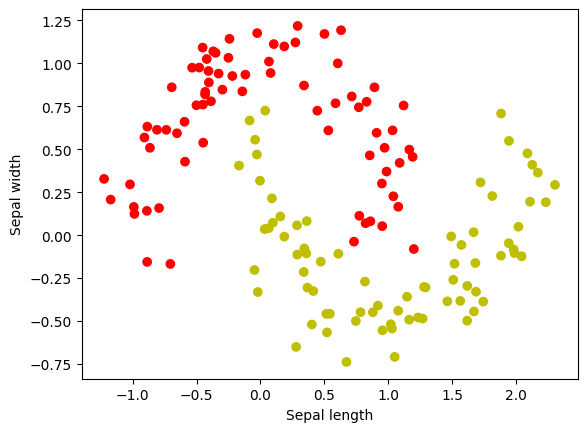

In [2]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [3]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [4]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [5]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [6]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [7]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.0066)


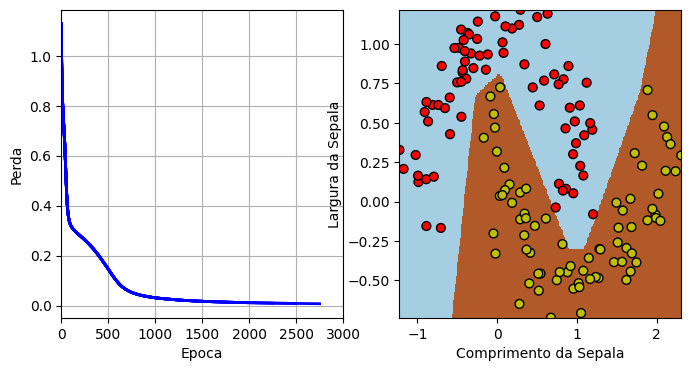

In [8]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [9]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[ 2.7025,  0.0772],
        [-0.3777,  0.0329],
        [ 2.0402,  1.5692],
        [-1.8845,  0.2771],
        [-1.9043,  0.5522]])
dense.0.bias    torch.Size([5])
tensor([-2.4259, -0.6605, -0.5220, -0.1798, -0.3298])
dense.2.weight  torch.Size([5, 5])
tensor([[-0.4564,  0.2233,  1.8605,  1.1642,  1.1960],
        [ 0.1018, -0.4281,  0.6019, -0.2420,  0.2196],
        [ 1.8574,  0.4207, -1.7057, -1.5720, -1.4974],
        [ 2.9850,  0.1050, -0.2437, -0.0846, -0.2814],
        [ 0.6838,  0.3828, -0.0437, -0.2199, -0.4371]])
dense.2.bias    torch.Size([5])
tensor([ 0.6097, -0.2290,  2.5785, -1.1372, -0.4778])
dense.4.weight  torch.Size([3, 5])
tensor([[ 1.9121,  0.5583, -2.5485, -2.0302, -0.6399],
        [-1.2325, -0.1037,  3.2057,  2.4453,  0.5547],
        [-1.2261,  0.2046, -0.9392, -0.3192,  0.3565]])
dense.4.bias    torch.Size([3])
tensor([ 0.2800,  0.7982, -0.9172])


### Avaliação do classificador

In [10]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  1.0


### Matriz de confusão

In [11]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,75,0
1,0,75


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

## Principais aprendizados

1. Faça alterações na rede, alterando o número de neurônios e de camadas. Escreva suas conclusões.

Quando aumentei a quantidade de neurônios e adicionei mais uma camada, a rede conseguiu separar melhor os dados. Com poucos neurônios o resultado ficou mais simples e a fronteira de decisão não ficou tão boa. Também percebi que aumentar muito a rede não trouxe uma melhora tão grande para esse conjunto de dados.

2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.

Usando Sigmoid a rede continuou funcionando, mas o treinamento ficou mais lento. O erro demorou mais para diminuir e o resultado final foi um pouco pior do que com ReLU. A ReLU pareceu aprender mais rápido.

3. O que ocorre quando não se utiliza ativação não linear entre camadas?

Sem uma função de ativação entre as camadas, a rede perde boa parte da sua capacidade de aprendizado. Mesmo tendo várias camadas, ela acaba se comportando como um modelo linear e tem mais dificuldade para separar dados mais complexos.

Principais aprendizados

A quantidade de neurônios influencia no resultado da rede.

Adicionar camadas pode melhorar o aprendizado em alguns casos.

A função de ativação faz bastante diferença no desempenho.

A ReLU treinou mais rápido do que a Sigmoid nos testes realizados.

Sem ativação não linear a rede fica limitada e aprende menos.


## Código complementar dos experimentos

In [12]:
# Código usado para realizar os testes da atividade
# Mantive o mesmo tipo de base do notebook: make_moons, com 150 amostras e noise=0.15.

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn import datasets

torch.set_num_threads(1)

n_samples = 150
Xc, Y = datasets.make_moons(n_samples=n_samples, noise=.15, random_state=42)

X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

def treinar_modelo(hidden_layers, activation="relu", epochs=3000, lr=0.15, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    camadas = []
    entrada = 2

    if activation == "relu":
        ativacao = nn.ReLU
    elif activation == "sigmoid":
        ativacao = nn.Sigmoid
    elif activation == "none":
        ativacao = None
    else:
        raise ValueError("activation deve ser relu, sigmoid ou none")

    for n in hidden_layers:
        camadas.append(nn.Linear(entrada, n))

        if ativacao is not None:
            camadas.append(ativacao())

        entrada = n

    camadas.append(nn.Linear(entrada, 3))

    model = nn.Sequential(*camadas)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoca in range(epochs):
        output = model(X_tensor)
        loss = criterion(output, Y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        pred = torch.argmax(model(X_tensor), dim=1).numpy()
        accuracy = (pred == Y).mean()

    return float(loss.detach()), float(accuracy)

experimentos = [
    ["Rede original", [5, 5], "relu"],
    ["Mais neurônios", [20, 20], "relu"],
    ["Mais camadas", [20, 10, 5], "relu"],
    ["Trocando ReLU por Sigmoid", [20, 20], "sigmoid"],
    ["Sem ativação não linear", [20, 20], "none"],
]

resultados = []

for nome, camadas, ativacao in experimentos:
    loss_final, acuracia = treinar_modelo(camadas, ativacao)

    resultados.append({
        "Experimento": nome,
        "Camadas ocultas": str(camadas),
        "Ativação": ativacao,
        "Loss final": round(loss_final, 4),
        "Acurácia": round(acuracia, 4)
    })

resultados_df = pd.DataFrame(resultados)
resultados_df


,Experimento,Camadas ocultas,Ativação,Loss final,Acurácia
0,Rede original,"[5, 5]",relu,0.2588,0.8733
1,Mais neurônios,"[20, 20]",relu,0.0024,1.0000
2,Mais camadas,"[20, 10, 5]",relu,0.0005,1.0000
3,Trocando ReLU por Sigmoid,"[20, 20]",sigmoid,0.3020,0.8533
4,Sem ativação não linear,"[20, 20]",none,0.2995,0.8533
